In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
short_order = [
 'TriComm KAN no drug',
 'TriComm PVI no drug',
 'TriComm PVI 16x MIC',
 'TriComm KAN+PVI no drug',
 'TriComm KAN+PVI 16x MIC',
 'TriComm PVB no drug',
 'TriComm PVB 16x MIC',
]
short_order_2 = [
 'TriComm PVI no drug',
 'TriComm PVI 16x MIC',
 'TriComm KAN+PVI no drug',
 'TriComm KAN+PVI 16x MIC',
 'TriComm PVB no drug',
 'TriComm PVB 16x MIC',
]

In [4]:
m = pd.read_csv('references_collated.csv')

In [5]:
n = m[(m['data_type'] == 'output') &
      (m['replicate'].str.startswith('pOXA48')) &
      (m['reference_name'] != 'NZ_CP009273') &
      (~m['sample_name'].str.contains('clone')) &
      (~m['sample_name'].str.endswith('M9'))].pivot_table(
        index=['experiment_name', 'sample_name', 'replicate'],
        columns='reference_name',
        values='coverage_average').reset_index()

In [6]:
c = m[(m['data_type'] == 'output') &
      (m['replicate'].str.startswith('pOXA48')) &
      (m['reference_name'] != 'NZ_CP009273') &
      (m['sample_name'].str.contains('clone'))].pivot_table(
        index=['experiment_name', 'sample_name', 'replicate'],
        columns='reference_name',
        values='coverage_average').reset_index()

In [7]:
n['replicate'] = n['replicate'].str.replace('pOXA48_', '')
n['time'] = n['sample_name'].str.split('_').str[1].str.replace('h', '')
n['time'] = n['time'].astype(float)

In [8]:
c['replicate'] = c['replicate'].str.replace('pOXA48_', '')
c['clone'] = c['sample_name'].str.split('_').str[1]
c['clone_replicate'] = c['sample_name'].str.split('_').str[-1]

In [9]:
n.rename(columns={'NZ_MT441554': 'pOXA48',
                  'pS2313M_msfGFP': 'pS2313M msfGFP',
                  'pS2313RS_mScarle': 'pS2313RS mScarlet'}, inplace=True)
c.rename(columns={'NZ_MT441554': 'pOXA48',
                  'pS2313M_msfGFP': 'pS2313M msfGFP',
                  'pS2313RS_mScarle': 'pS2313RS mScarlet'}, inplace=True)

In [10]:
n = n.set_index(['experiment_name', 'sample_name', 'replicate', 'time']
               ).stack().reset_index().rename(columns={0: 'coverage',
                                                       'reference_name': 'replicon'})
n['coverage+1'] = n['coverage'] + 1

In [11]:
c = c.set_index(['experiment_name', 'sample_name', 'replicate', 'clone', 'clone_replicate']
               ).stack().reset_index().rename(columns={0: 'coverage',
                                                       'reference_name': 'replicon'})
c['coverage+1'] = c['coverage'] + 1

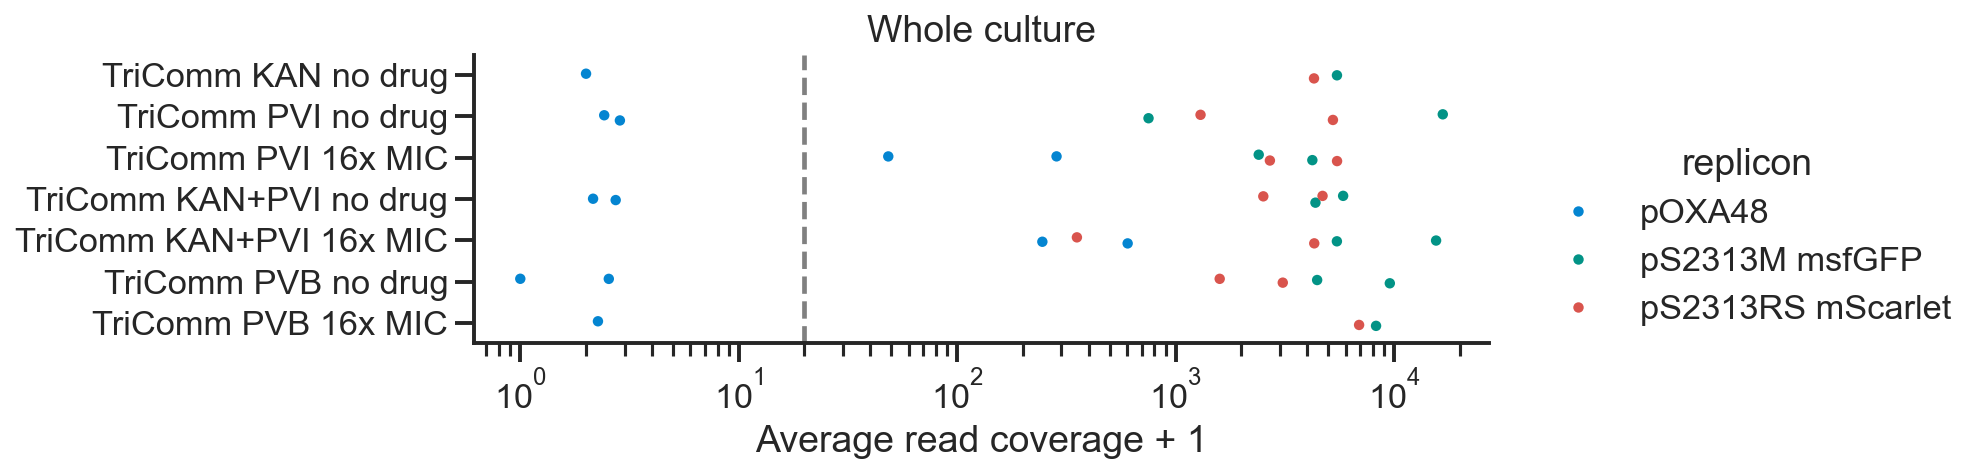

In [12]:
cp = sns.catplot(data=n,
            x='coverage+1',
            hue='replicon',
            y='experiment_name',
            palette=['xkcd:cerulean', 'xkcd:teal',
                     'xkcd:pale red'],
            # marker='replicate',
            height=3.5, aspect=3.,
            order=short_order,
            # legend=False
            )

cp.set(xscale='log',
       ylabel='',
       xlabel='Average read coverage + 1',
       title='Whole culture')

cp.map(plt.axvline, x=20, color='grey', linestyle='--')

plt.savefig('whole_coverage.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('whole_coverage.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);

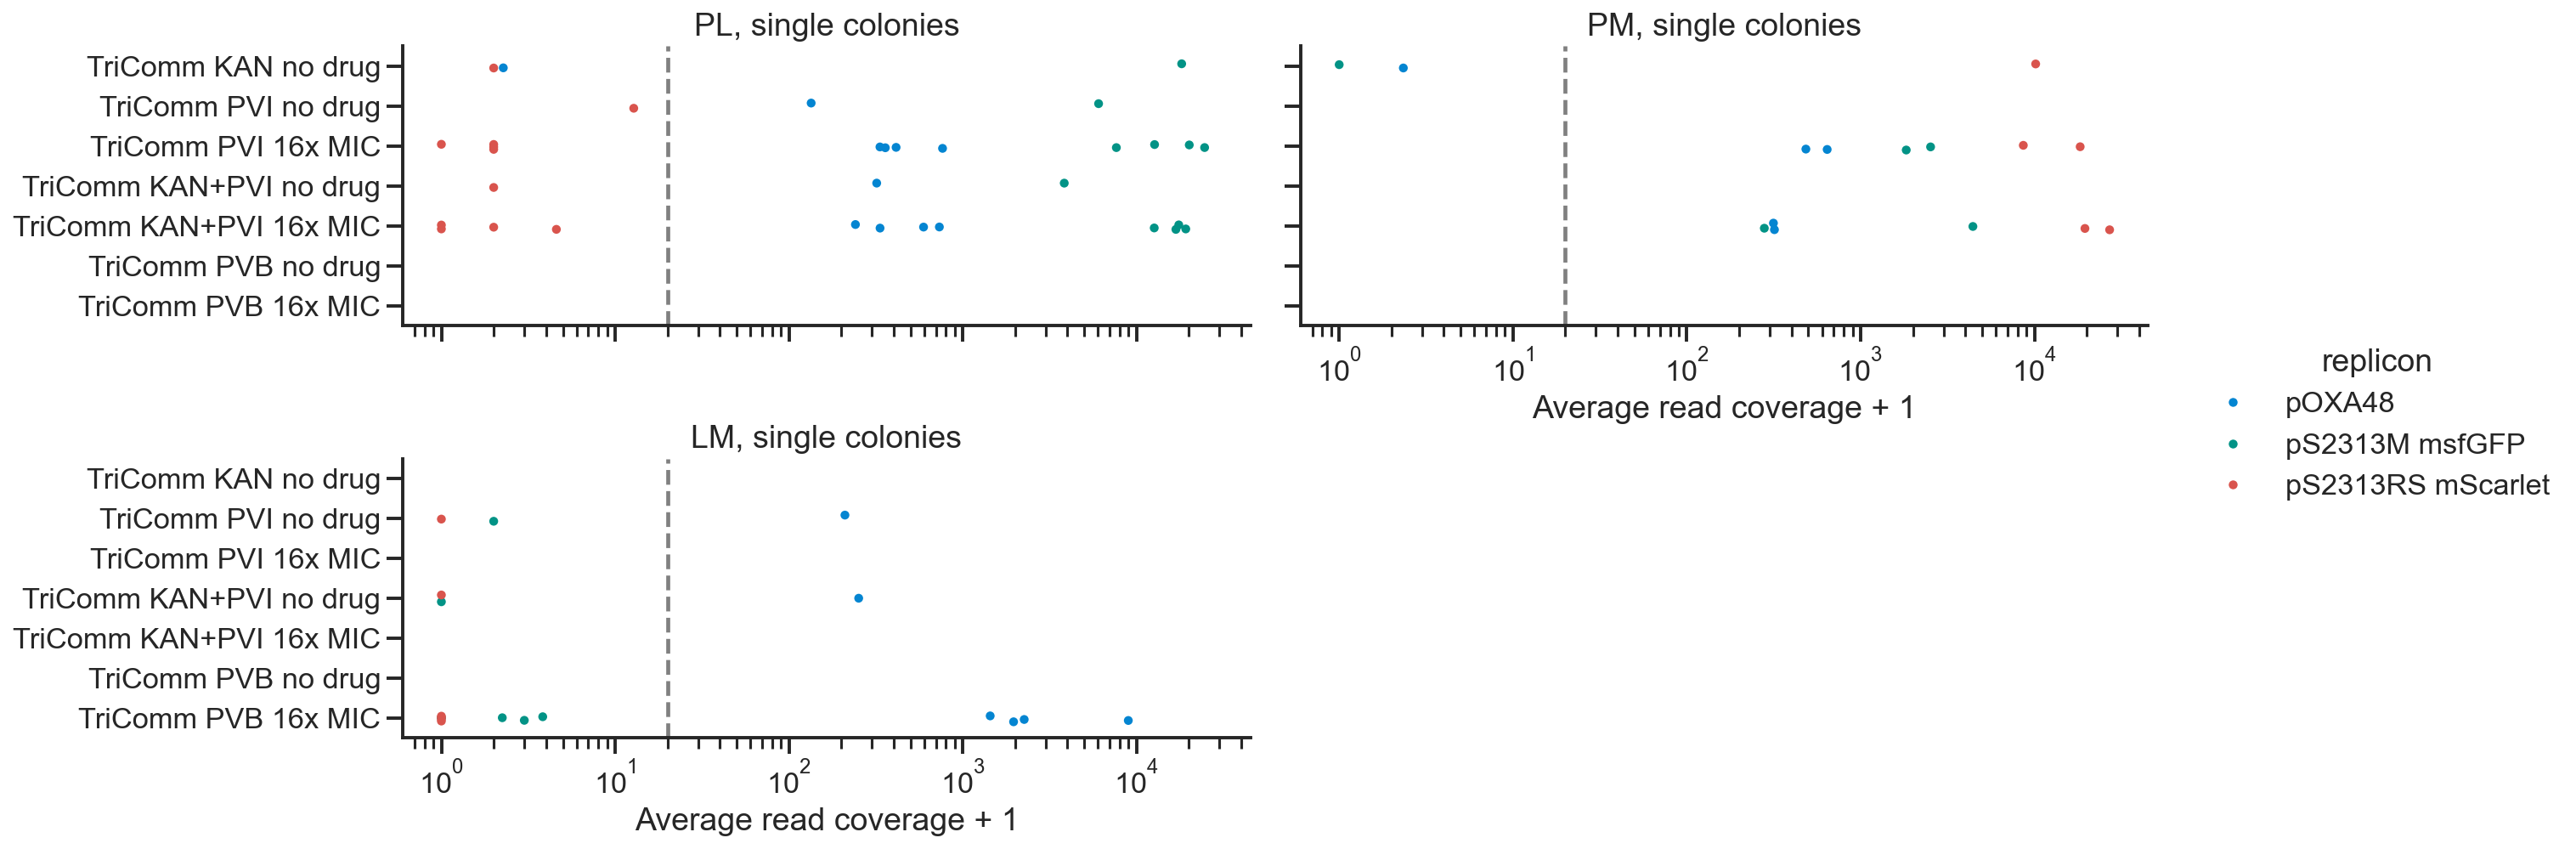

In [13]:
cp = sns.catplot(data=c,
            x='coverage+1',
            hue='replicon',
            y='experiment_name',
            col='clone',
            col_wrap=2,
            palette=['xkcd:cerulean', 'xkcd:teal',
                     'xkcd:pale red'],
            # marker='replicate',
            height=3.5, aspect=2.5,
            order=short_order)

cp.set(xscale='log',
       ylabel='',
       xlabel='Average read coverage + 1')

cp.set_titles(col_template='{col_name}, single colonies')

cp.map(plt.axvline, x=20, color='grey', linestyle='--')

plt.savefig('clones_coverage.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('clones_coverage.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);

In [14]:
short_order_pn23 = [
 'TriComm KAN no drug',
 'TriComm PN23 no drug',
 'TriComm KAN 1xMIC',
 'TriComm PN23 1xMIC',
 'TriComm KAN 2xMIC',
 'TriComm PN23 2xMIC'
]

In [15]:
n_pn23 = m[(m['data_type'] == 'output') &
           (m['replicate'].str.startswith('PN23')) &
           (m['reference_name'] != 'NZ_CP009273') &
           (~m['sample_name'].str.contains('clone'))].pivot_table(
             index=['experiment_name', 'sample_name', 'replicate'],
             columns='reference_name',
             values='coverage_average').reset_index()

c_pn23 = m[(m['data_type'] == 'output') &
           (m['replicate'].str.startswith('PN23')) &
           (m['reference_name'] != 'NZ_CP009273') &
           (m['sample_name'].str.contains('clone'))].pivot_table(
             index=['experiment_name', 'sample_name', 'replicate'],
             columns='reference_name',
             values='coverage_average').reset_index()

print('Whole-culture PN23 rows:', len(n_pn23))
print('Clone PN23 rows:', len(c_pn23))


Whole-culture PN23 rows: 1
Clone PN23 rows: 4


In [16]:
# PN23: extract time from sample name for whole-culture
n_pn23['replicate'] = n_pn23['replicate'].str.replace('PN23_', '')
n_pn23['time'] = n_pn23['sample_name'].str.split('_').str[1].str.replace('h', '')
n_pn23['time'] = n_pn23['time'].astype(float)

# PN23: extract clone info for single-colony
c_pn23['replicate'] = c_pn23['replicate'].str.replace('PN23_', '')
c_pn23['clone'] = c_pn23['sample_name'].str.split('_').str[1]
c_pn23['clone_replicate'] = c_pn23['sample_name'].str.split('_').str[-1]


In [17]:
# PN23: rename columns for readability
n_pn23.rename(columns={'MG557852': 'PN23',
                       'pS2313M_msfGFP': 'pS2313M msfGFP',
                       'pS2313RS_mScarle': 'pS2313RS mScarlet'}, inplace=True)
c_pn23.rename(columns={'MG557852': 'PN23',
                       'pS2313M_msfGFP': 'pS2313M msfGFP',
                       'pS2313RS_mScarle': 'pS2313RS mScarlet'}, inplace=True)

# PN23: stack into long form for catplot
n_pn23 = n_pn23.set_index(['experiment_name', 'sample_name', 'replicate', 'time']
                    ).stack().reset_index().rename(columns={0: 'coverage',
                                                            'reference_name': 'replicon'})
n_pn23['coverage+1'] = n_pn23['coverage'] + 1

c_pn23 = c_pn23.set_index(['experiment_name', 'sample_name', 'replicate', 'clone', 'clone_replicate']
                    ).stack().reset_index().rename(columns={0: 'coverage',
                                                            'reference_name': 'replicon'})
c_pn23['coverage+1'] = c_pn23['coverage'] + 1


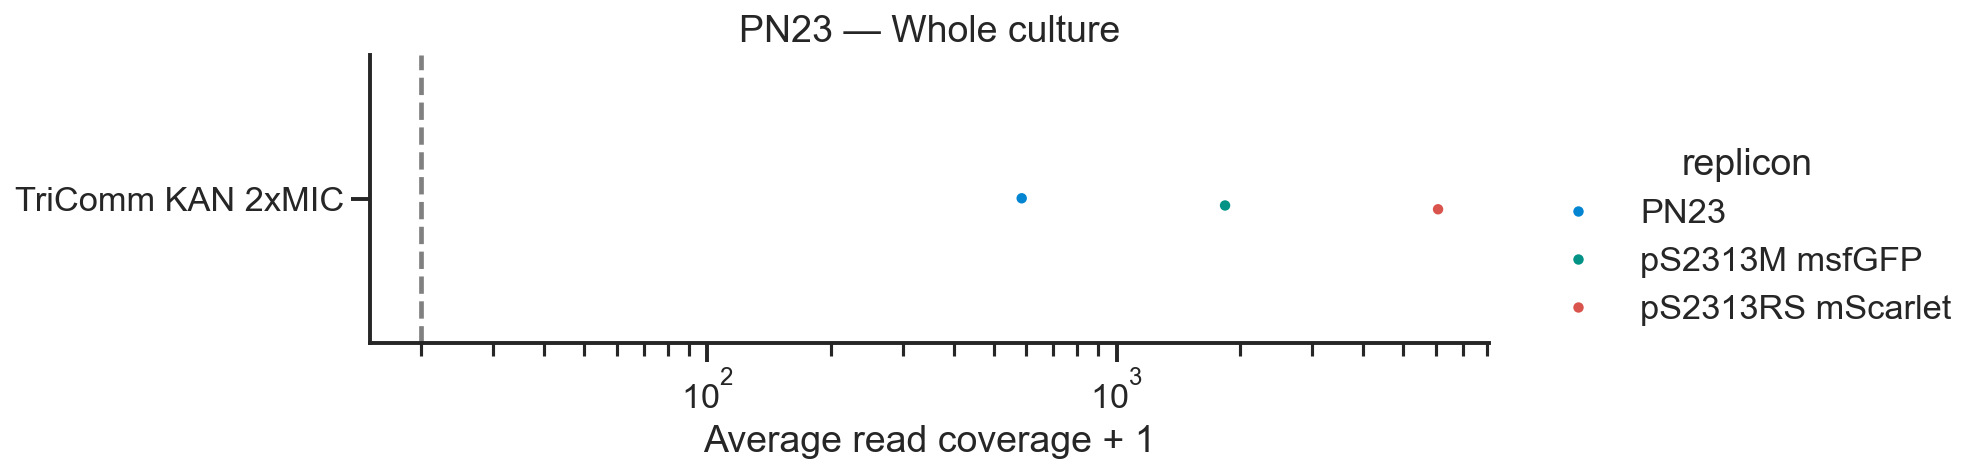

In [18]:
cp_pn23 = sns.catplot(data=n_pn23,
            x='coverage+1',
            hue='replicon',
            y='experiment_name',
            palette=['xkcd:cerulean', 'xkcd:teal',
                     'xkcd:pale red'],
            height=3.5, aspect=3.,
            # order=short_order_pn23,
            )

cp_pn23.set(xscale='log',
       ylabel='',
       xlabel='Average read coverage + 1',
       title='PN23 — Whole culture')

cp_pn23.map(plt.axvline, x=20, color='grey', linestyle='--')

plt.savefig('whole_coverage_pn23.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('whole_coverage_pn23.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);


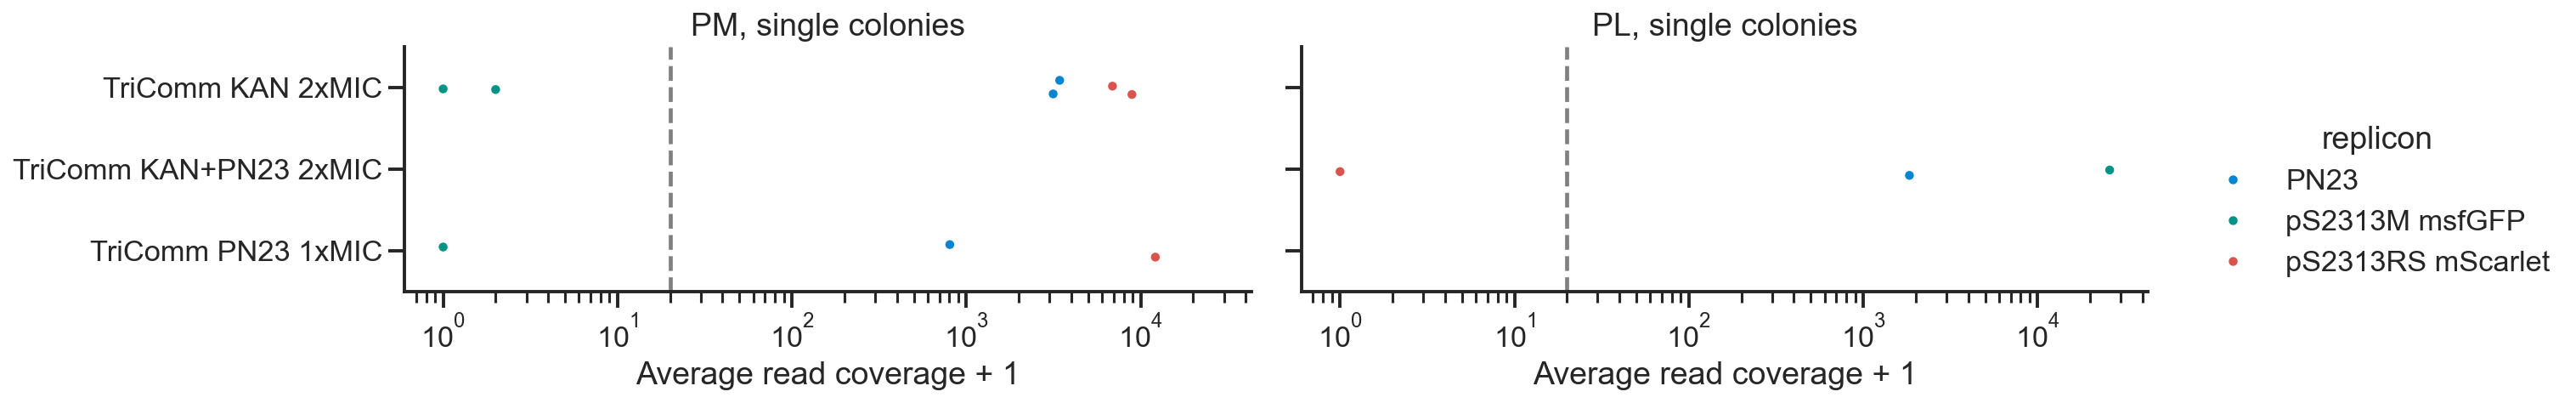

In [19]:
cp_pn23_clones = sns.catplot(data=c_pn23,
            x='coverage+1',
            hue='replicon',
            y='experiment_name',
            col='clone',
            col_wrap=2,
            palette=['xkcd:cerulean', 'xkcd:teal',
                     'xkcd:pale red'],
            height=3.5, aspect=2.5,
            # order=short_order_pn23
                            )

cp_pn23_clones.set(xscale='log',
       ylabel='',
       xlabel='Average read coverage + 1')

cp_pn23_clones.set_titles(col_template='{col_name}, single colonies')

cp_pn23_clones.map(plt.axvline, x=20, color='grey', linestyle='--')

plt.savefig('clones_coverage_pn23.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('clones_coverage_pn23.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);
